<a href="https://colab.research.google.com/github/wesleylelo/CDIA_AI_COLAB/blob/develop/APRENDIZADO_REFORCO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
###################################################################
##################################################################
#Instituição: SENAI - CIMATEC
#Curso: Ciência de Dados e Inteligência Artificial (CDIA)
#Disciplina: Inteligência Artificial II
#Autor: Carlos Fernando Arraz | Data: Abril, 2024
#UA07 - Roteiro de Prática Guiada 01: Teoria sobre RL
###################################################################
###################################################################

---

INSTRUÇÕES GERAIS:

---



1 - Realize uma cópia deste arquivo em seu repositório pessoal para iniciar a prática (usar o e-mail institucional para isso);

2 - Reveja o conteúdo teórico e os exemplos práticos vistos até agora na graduação para pontecializar o aprendizado;

3 -Leia a teoria e acompanhe o script python linha a linha e seus comentários (execute as células com **shift + ENTER** ou botão play à esquerda de cada comando/bloco de código), estudando as estruturas, as partes do algoritmo e a lógica proposta;

4 - Execute, modifique, teste e experimente o conteúdo ao máximo para internalizar o conhecimento; e

5- Compare os resultados com bibliotecas de machine learning consagradas no desenvolvimento de soluções em AI.

#Este roteiro tem como objetivo mostrar experimentos acerca da teoria por detrás da RL, tais como MDP e função valor acão-recompensa, tudo isso através de um script em python 🐍.

**Este roteiro tem 2 partes:**

Na **Parte I**, veremos uma aplicação simulando o que vimos na teoria sobre a função de valor ação-recompensa. Já na **Parte II**, veremos algumas bases teóricas que suportam o aprendizado por reforço.

#PARTE I - Função valor ação-recompensa [4]

## Examplo de uma função de valor ação-recompensa

Neste notebook Jupyter, você pode modificar o exemplo do Mars Rover para ver como os valores de *Q(s,a)* mudarão dependendo das recompensas e da mudança do fator de desconto.

In [7]:
import numpy as np
from utils import *  #faça o download do arquivo utils.py e carrega no diretorio
                     # do google colab

import matplotlib.pyplot as plt

In [8]:
# Favor não modifique
num_states = 6
num_actions = 2

In [ ]:
terminal_left_reward = 100
terminal_right_reward = 40
each_step_reward = 0

# Fator de desconto (modifique e veja a diferença)
gamma = 0.5



#ATENÇÂO: Usar esta parte (alterar para valores maiores que 0) quando for
# estudado nos próximos recursos quando há a probabilidade de ir numa direção
#errada, ou seja, não há certeza que a ação será bem sucedida.
misstep_prob = 0

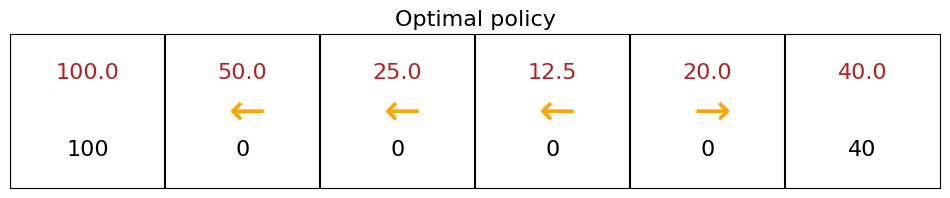

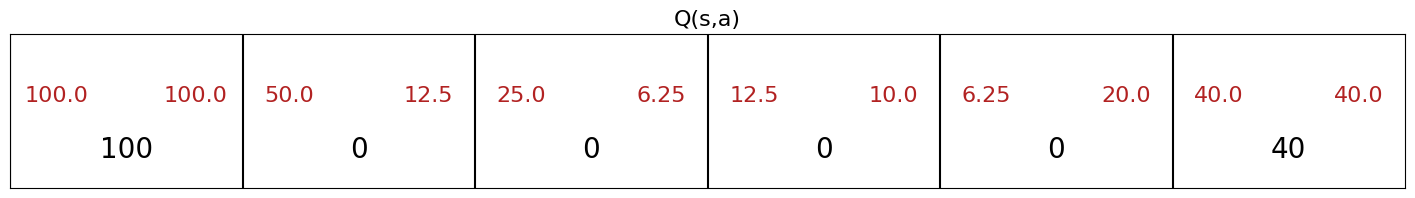

In [ ]:
generate_visualization(terminal_left_reward, terminal_right_reward, each_step_reward, gamma, misstep_prob)

# PARTE II - Suporte Teórico do RL

**Obs: Para este parte II e um melhor aproveitamento do conteúdo, voce deverá acompnhar o capítulo do livro [1] referente a este lab.**

As seguintes probabilidades de transição correspondem à Cadeia de Markov representada em [1]. Vamos executar esse processo estocástico algumas vezes para ver como fica:

## Cadeia de Markov

In [ ]:
}np.random.seed(42)

transition_probabilities = [ # shape=[s, s']
        [0.7, 0.2, 0.0, 0.1],  # from s0 to s0, s1, s2, s3
        [0.0, 0.0, 0.9, 0.1],  # from s1 to s0, s1, s2, s3
        [0.0, 1.0, 0.0, 0.0],  # from s2 to s0, s1, s2, s3
        [0.0, 0.0, 0.0, 1.0]]  # from s3 to s0, s1, s2, s3

n_max_steps = 1000  # to avoid blocking in case of an infinite loop
terminal_states = [3]

def run_chain(start_state):
    current_state = start_state
    for step in range(n_max_steps):
        print(current_state, end=" ")
        if current_state in terminal_states:
            break
        current_state = np.random.choice(
            range(len(transition_probabilities)),
            p=transition_probabilities[current_state]
        )
    else:
        print("...", end="")

    print()

for idx in range(10):
    print(f"Run #{idx + 1}: ", end="")
    run_chain(start_state=0)

Run #1: 0 0 3 
Run #2: 0 1 2 1 2 1 2 1 2 1 3 
Run #3: 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 3 
Run #4: 0 3 
Run #5: 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 3 
Run #6: 0 1 3 
Run #7: 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 3 
Run #8: 0 0 0 1 2 1 2 1 3 
Run #9: 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 3 
Run #10: 0 0 0 1 2 1 3 


## O processo de decisão de Markov (MDP)

Vamos definir algumas probabilidades de transição, recompensas e ações possíveis. Por exemplo, no estado s0, se a ação a0 for escolhida então com probabilidade 0,7 iremos para o estado s0 com recompensa +10, com probabilidade 0,3 iremos para o estado s1 sem recompensa, e com nunca iremos para o estado s2 (então o as probabilidades de transição são `[0,7, 0,3, 0,0]` e as recompensas são `[+10, 0, 0]`):

In [ ]:
transition_probabilities = [  # shape=[s, a, s']
    [[0.7, 0.3, 0.0], [1.0, 0.0, 0.0], [0.8, 0.2, 0.0]],
    [[0.0, 1.0, 0.0], None, [0.0, 0.0, 1.0]],
    [None, [0.8, 0.1, 0.1], None]
]
rewards = [  # shape=[s, a, s']
    [[+10, 0, 0], [0, 0, 0], [0, 0, 0]],
    [[0, 0, 0], [0, 0, 0], [0, 0, -50]],
    [[0, 0, 0], [+40, 0, 0], [0, 0, 0]]
]
possible_actions = [[0, 1, 2], [0, 2], [1]]

## Iteração Q-Value

In [ ]:
Q_values = np.full((3, 3), -np.inf)  # -np.inf for impossible actions
for state, actions in enumerate(possible_actions):
    Q_values[state, actions] = 0.0  # for all possible actions

In [ ]:
gamma = 0.90  # the discount factor

history1 = []  # extra code – needed for the figure below
for iteration in range(50):
    Q_prev = Q_values.copy()
    history1.append(Q_prev) # extra code
    for s in range(3):
        for a in possible_actions[s]:
            Q_values[s, a] = np.sum([
                    transition_probabilities[s][a][sp]
                    * (rewards[s][a][sp] + gamma * Q_prev[sp].max())
                for sp in range(3)])

history1 = np.array(history1)  # extra code

In [ ]:
Q_values

array([[18.91891892, 17.02702702, 13.62162162],
       [ 0.        ,        -inf, -4.87971488],
       [       -inf, 50.13365013,        -inf]])

In [ ]:
Q_values.argmax(axis=1)  # optimal action for each state

array([0, 0, 1])

A política ótima para este MDP, ao usar um fator de desconto de 0,90, é escolher a ação a0 quando estiver no estado s0, e escolher a ação a0 quando estiver no estado s1, e finalmente escolher a ação a1 (a única ação possível) quando estiver no estado s2. Se você tentar novamente com um fator de desconto de 0,95 em vez de 0,90, verá que a ação ideal para o estado s1 se torna a2. Isso ocorre porque o fator de desconto é maior, de modo que o agente valoriza mais o futuro e, portanto, está pronto para pagar uma multa imediata para obter mais recompensas futuras.

## Q-Learning

O Q-Learning funciona observando um agente jogar (por exemplo, aleatoriamente) e melhorando gradualmente suas estimativas dos Q-Values. Uma vez que tenha estimativas precisas de Q-Value (ou próximas o suficiente), então a política ótima consiste em escolher a ação que tem o maior Q-Value (ou seja, a política gananciosa).

Precisaremos simular um agente se movimentando no ambiente, então vamos definir uma função para realizar alguma ação e obter o novo estado e uma recompensa:

In [ ]:
def step(state, action):
    probas = transition_probabilities[state][action]
    next_state = np.random.choice([0, 1, 2], p=probas)
    reward = rewards[state][action][next_state]
    return next_state, reward

Também precisamos de uma política de exploração, que pode ser qualquer política, desde que visite todos os estados possíveis muitas vezes. Usaremos apenas uma política aleatória, já que o espaço de estados é muito pequeno:

In [ ]:
def exploration_policy(state):
    return np.random.choice(possible_actions[state])

Agora vamos inicializar os Q-Values como antes e executar o algoritmo Q-Learning:

In [ ]:
# extra code – initializes the Q-Values, just like earlier
np.random.seed(42)
Q_values = np.full((3, 3), -np.inf)
for state, actions in enumerate(possible_actions):
    Q_values[state][actions] = 0

In [ ]:
alpha0 = 0.05  # initial learning rate
decay = 0.005  # learning rate decay
gamma = 0.90  # discount factor
state = 0  # initial state
history2 = []  # extra code – needed for the figure below

for iteration in range(10_000):
    history2.append(Q_values.copy())  # extra code
    action = exploration_policy(state)
    next_state, reward = step(state, action)
    next_value = Q_values[next_state].max()  # greedy policy at the next step
    alpha = alpha0 / (1 + iteration * decay)
    Q_values[state, action] *= 1 - alpha
    Q_values[state, action] += alpha * (reward + gamma * next_value)
    state = next_state

history2 = np.array(history2)  # extra code

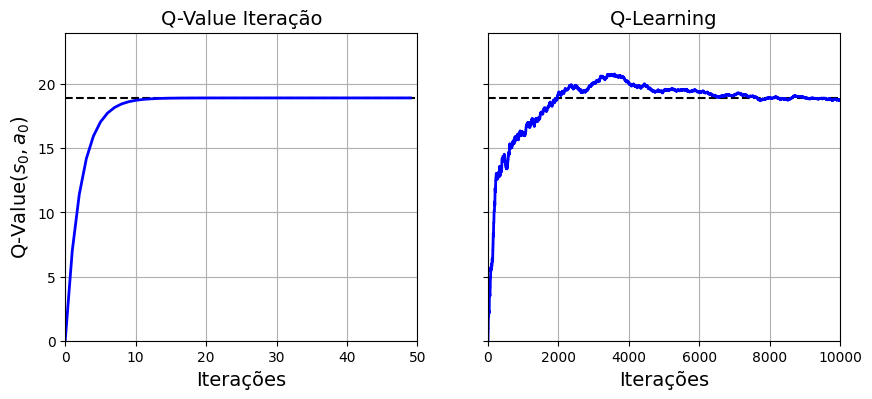

In [ ]:
true_Q_value = history1[-1, 0, 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].set_ylabel("Q-Value$(s_0, a_0)$", fontsize=14)
axes[0].set_title("Q-Value Iteração", fontsize=14)
axes[1].set_title("Q-Learning", fontsize=14)
for ax, width, history in zip(axes, (50, 10000), (history1, history2)):
    ax.plot([0, width], [true_Q_value, true_Q_value], "k--")
    ax.plot(np.arange(width), history[:, 0, 0], "b-", linewidth=2)
    ax.set_xlabel("Iterações", fontsize=14)
    ax.axis([0, width, 0, 24])
    ax.grid(True)

plt.savefig("q_value_plot")
plt.show()

**Referências:**

Código adaptado. disponível: https://github.com/ageron/handson-ml3/blob/main/18_reinforcement_learning.ipynb. Acesso em: 01 maio 2024.

Código adaptado. Machine Learning Specialization, Stanford e Deeplearning.ai . Disponível em: https://github.com/https-deeplearning-ai. Acesso em: 01 maio 2024.

FACELI, Katti; et al. Inteligência artificial: uma abordagem de aprendizado de máquina. Rio de Janeiro: Grupo GEN, 2021. E-book. ISBN 9788521637509.

GÉRON, Aurélien. Mãos à Obra: Aprendizado de Máquina com Scikit-Learn, Keras & TensorFlow: Conceitos, Ferramentas e Técnicas para a Construção de Sistemas Inteligentes. Editora Alta Books, 2021. E-book. ISBN 9786555208146. Disponível em: https://integrada.minhabiblioteca.com.br/#/books/9786555208146/ . Acesso em: 25 fev. 2024.

JAMES, G.*et al*. An introduction to statistical learning: With applications in python. Springer Nature. 2023


